In [2]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Step 1 — Load the Dataset

Online Shoppers Purchasing Intention Dataset from UCI Machine Learning Repository
https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset


In [4]:

df = pd.read_csv('online_shoppers_intention.csv')

# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [5]:
# Dataset shape
print("\nDataset Shape:", df.shape)

# Data types
print("\nColumn names and data types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics:")
df.describe()


Dataset Shape: (12330, 18)

Column names and data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

Summary Statistics:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Step 2 — Exploratory Data Analysis (EDA)

Revenue distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Percentage:
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


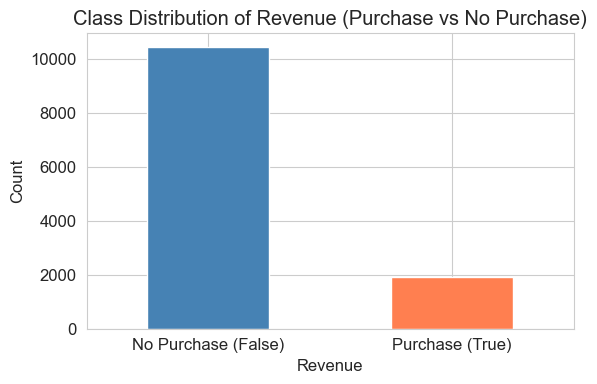

In [6]:
# Class Distribution (Revenue)
print("Revenue distribution:")
print(df['Revenue'].value_counts())
print("\nPercentage:")
print(df['Revenue'].value_counts(normalize=True) * 100)

# Plot class distribution
plt.figure(figsize=(6, 4))
df['Revenue'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Class Distribution of Revenue (Purchase vs No Purchase)')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Purchase (False)', 'Purchase (True)'], rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

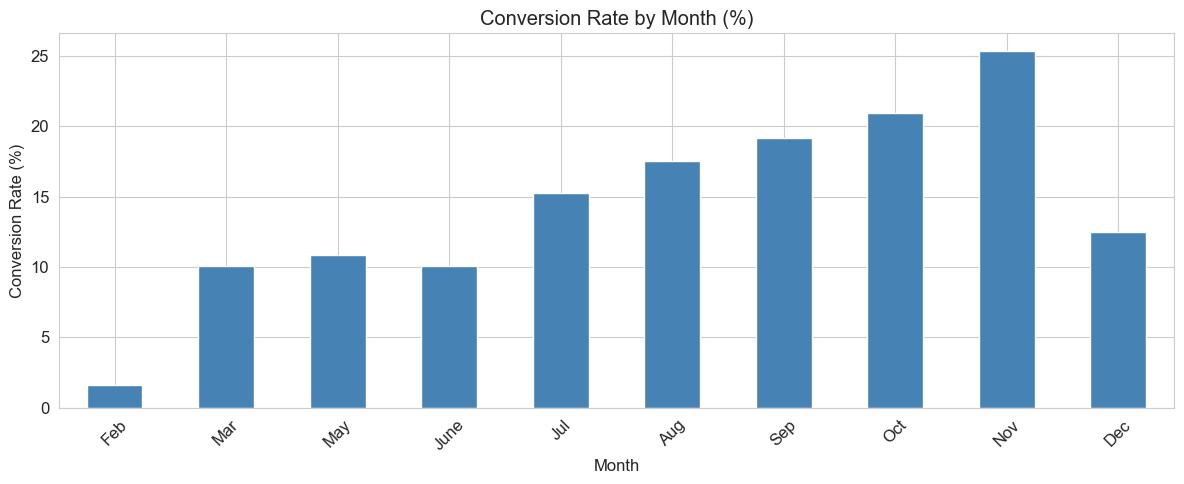

In [7]:
# Seasonal Pattern (Month vs Revenue)
plt.figure(figsize=(12, 5))
month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_conversion = df.groupby('Month')['Revenue'].mean() * 100
month_conversion = month_conversion.reindex(
    [m for m in month_order if m in month_conversion.index]
)
month_conversion.plot(kind='bar', color='steelblue')
plt.title('Conversion Rate by Month (%)')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_conversion.png', dpi=150)
plt.show()

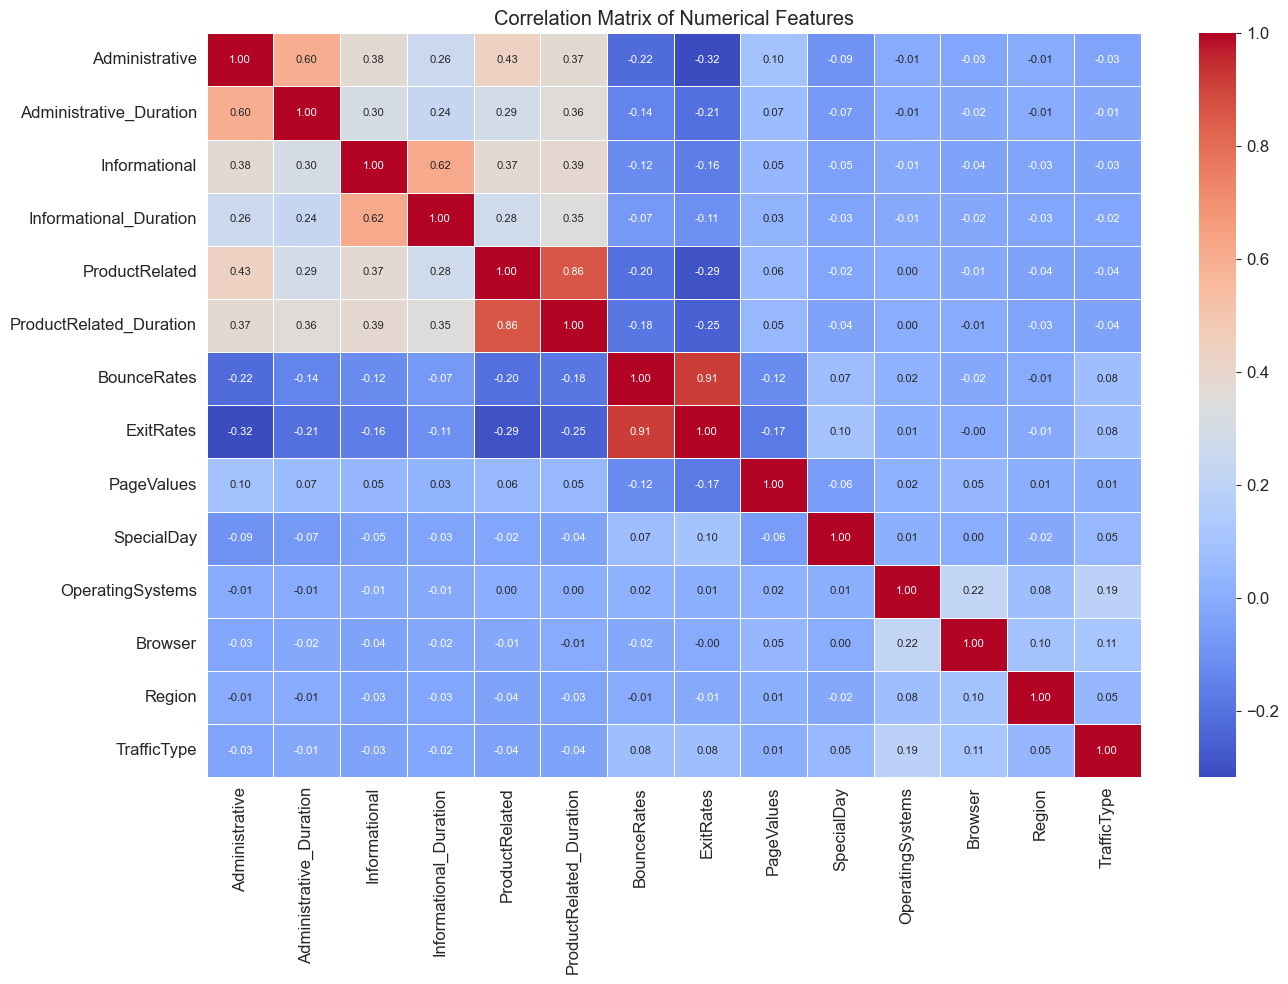

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

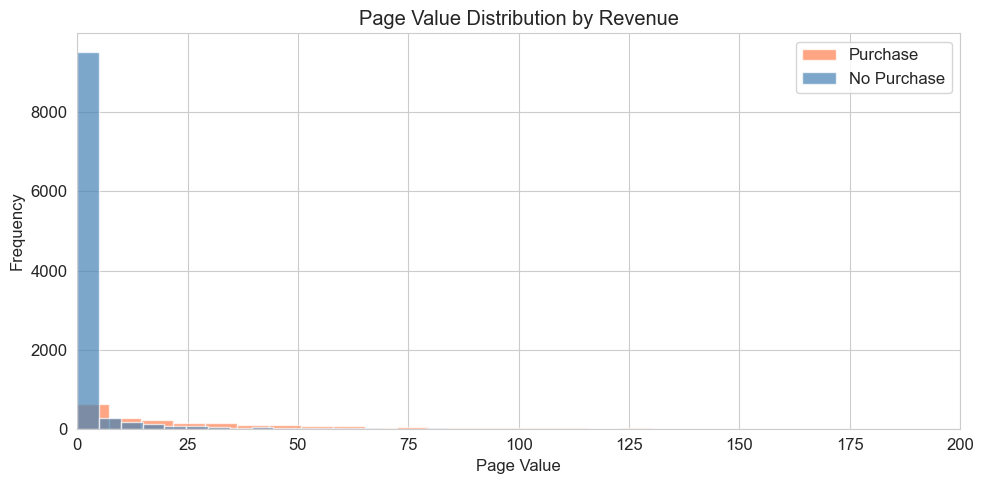

In [ ]:
# Page Value Distribution by Revenue
plt.figure(figsize=(10, 5))
df[df['Revenue'] == True]['PageValues'].hist(
    bins=50, alpha=0.7, color='coral', label='Purchase')
df[df['Revenue'] == False]['PageValues'].hist(
    bins=50, alpha=0.7, color='steelblue', label='No Purchase')
plt.title('Page Value Distribution by Revenue')
plt.xlabel('Page Value')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 200)
plt.tight_layout()
plt.savefig('pagevalue_distribution.png', dpi=150)
plt.show()


Conversion Rate by Visitor Type (%):
VisitorType
New_Visitor          24.911452
Other                18.823529
Returning_Visitor    13.932329
Name: Revenue, dtype: float64


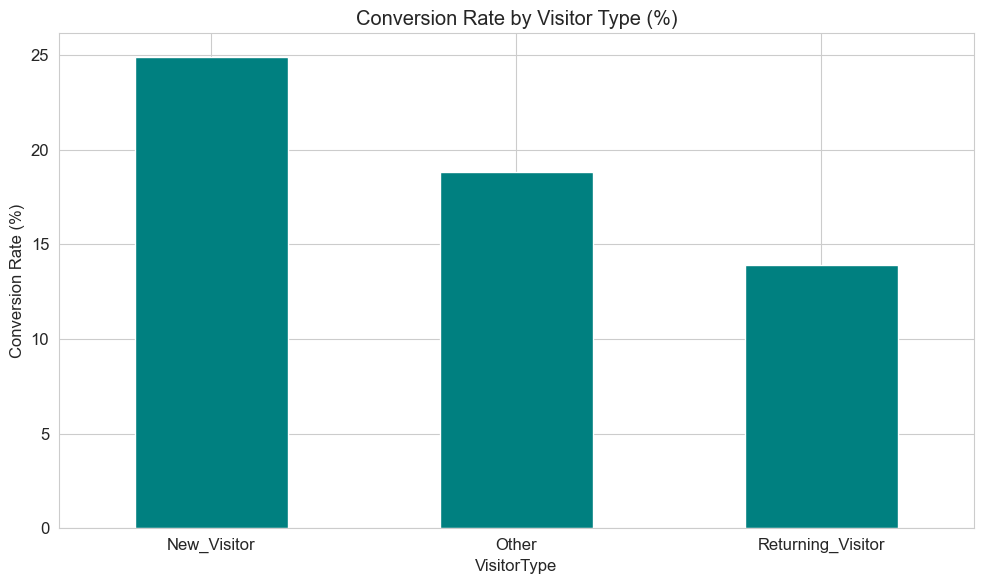

In [ ]:
# Visitor Type vs Conversion
visitor_conv = df.groupby('VisitorType')['Revenue'].mean() * 100
print("\nConversion Rate by Visitor Type (%):")
print(visitor_conv)

visitor_conv.plot(kind='bar', color='teal')
plt.title('Conversion Rate by Visitor Type (%)')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('visitortype_conversion.png', dpi=150)
plt.show()

Step 3 — Data Preprocessing

In [ ]:
# Separate Features and Target
X = df.drop('Revenue', axis=1).copy()
y = df['Revenue'].astype(int).copy()  # True=1, False=0

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (12330, 17)
Target distribution:
 Revenue
0    10422
1     1908
Name: count, dtype: int64


In [ ]:
# Label Encoding of Categorical Variables
le = LabelEncoder()

X['Month'] = le.fit_transform(X['Month'])
X['VisitorType'] = le.fit_transform(X['VisitorType'])
X['Weekend'] = X['Weekend'].astype(int)

print("\nAfter encoding - data types:")
print(X.dtypes)
print("\nFirst 5 rows after encoding:")
print(X.head())


After encoding - data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                      int64
dtype: object

First 5 rows after encoding:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0         

In [ ]:
# StandardScaler Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nAfter scaling - mean of each feature (should be ~0):")
print(X_scaled.mean().round(4))
print("\nAfter scaling - std of each feature (should be ~1):")
print(X_scaled.std().round(4))


After scaling - mean of each feature (should be ~0):
Administrative            -0.0
Administrative_Duration    0.0
Informational             -0.0
Informational_Duration    -0.0
ProductRelated             0.0
ProductRelated_Duration   -0.0
BounceRates               -0.0
ExitRates                  0.0
PageValues                 0.0
SpecialDay                 0.0
Month                      0.0
OperatingSystems          -0.0
Browser                    0.0
Region                     0.0
TrafficType               -0.0
VisitorType               -0.0
Weekend                   -0.0
dtype: float64

After scaling - std of each feature (should be ~1):
Administrative             1.0
Administrative_Duration    1.0
Informational              1.0
Informational_Duration     1.0
ProductRelated             1.0
ProductRelated_Duration    1.0
BounceRates                1.0
ExitRates                  1.0
PageValues                 1.0
SpecialDay                 1.0
Month                      1.0
OperatingS

Step 4 — Principal Component Analysis (PCA)

In [20]:
# Fit PCA to Find Number of Components for 95% Variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Print variance per component
print("Explained Variance per Component:")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"  PC{i+1}: {ev*100:.2f}%  |  Cumulative: {cv*100:.2f}%")

# Find number of components for 95% threshold
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")

Explained Variance per Component:
  PC1: 20.09%  |  Cumulative: 20.09%
  PC2: 10.57%  |  Cumulative: 30.67%
  PC3: 8.26%  |  Cumulative: 38.93%
  PC4: 6.97%  |  Cumulative: 45.89%
  PC5: 6.30%  |  Cumulative: 52.20%
  PC6: 6.03%  |  Cumulative: 58.23%
  PC7: 5.74%  |  Cumulative: 63.97%
  PC8: 5.61%  |  Cumulative: 69.59%
  PC9: 5.48%  |  Cumulative: 75.06%
  PC10: 5.13%  |  Cumulative: 80.20%
  PC11: 4.94%  |  Cumulative: 85.13%
  PC12: 4.74%  |  Cumulative: 89.87%
  PC13: 4.41%  |  Cumulative: 94.29%
  PC14: 2.48%  |  Cumulative: 96.76%
  PC15: 2.07%  |  Cumulative: 98.83%
  PC16: 0.72%  |  Cumulative: 99.55%
  PC17: 0.45%  |  Cumulative: 100.00%

Components needed for 95% variance: 14


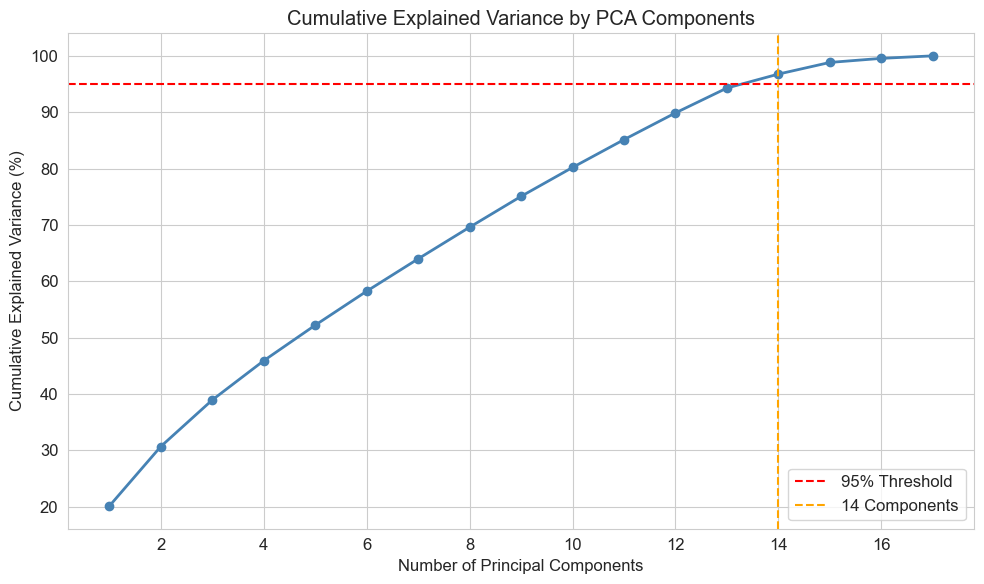

In [21]:
# Plot Cumulative Explained Variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance * 100, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=95, color='red', linestyle='--', label='95% Threshold')
plt.axvline(x=n_components_95, color='orange', linestyle='--',
            label=f'{n_components_95} Components')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()

In [22]:
# Apply Final PCA with Selected Components
pca = PCA(n_components=n_components_95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nOriginal feature dimensions: {X_scaled.shape[1]}")
print(f"PCA-reduced dimensions: {X_pca.shape[1]}")
print(f"Total variance retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")


Original feature dimensions: 17
PCA-reduced dimensions: 14
Total variance retained: 96.76%



PCA Component Loadings (top features per component):
                           PC1    PC2    PC3    PC4    PC5    PC6    PC7  \
Administrative           0.381  0.030  0.042  0.175  0.138  0.353  0.109   
Administrative_Duration  0.327  0.074  0.054  0.237  0.170  0.423  0.121   
Informational            0.346  0.244  0.000  0.240  0.078  0.367  0.199   
Informational_Duration   0.294  0.260  0.006  0.261  0.067  0.476  0.265   
ProductRelated           0.410  0.178  0.028  0.297  0.172  0.092  0.131   
ProductRelated_Duration  0.412  0.210  0.037  0.251  0.169  0.073  0.111   
BounceRates              0.279  0.551  0.038  0.208  0.102  0.188  0.046   
ExitRates                0.325  0.535  0.024  0.172  0.064  0.133  0.036   
PageValues               0.093  0.201  0.125  0.151  0.215  0.167  0.390   
SpecialDay               0.070  0.132  0.019  0.466  0.218  0.170  0.181   
Month                    0.044  0.028  0.064  0.395  0.585  0.164  0.079   
OperatingSystems         0.015  0.

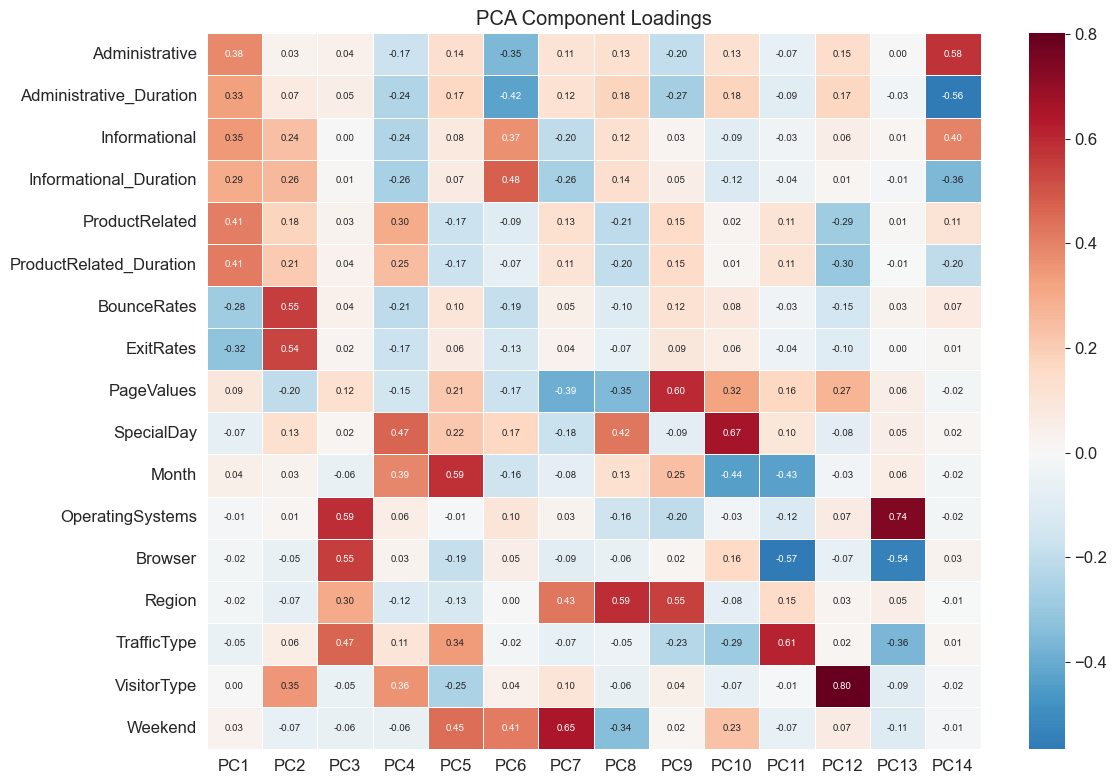

In [23]:
# PCA Component Loadings (Feature Contributions)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_95)],
    index=X.columns
)
print("\nPCA Component Loadings (top features per component):")
print(loadings.abs().round(3))

# Heatmap of loadings
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('PCA Component Loadings')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150)
plt.show()

Step 5 — K-Means Clustering

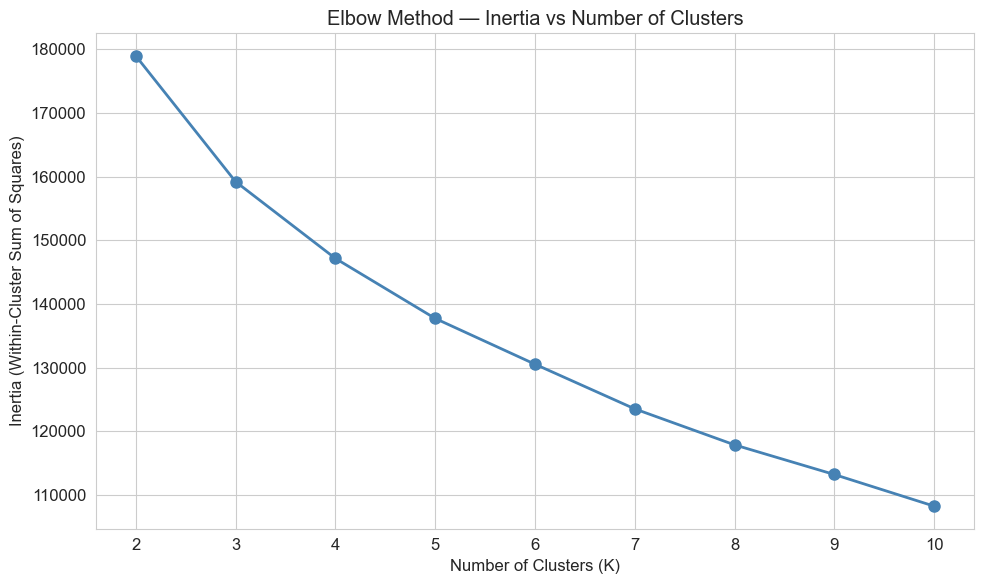

In [24]:
# Elbow Method
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Elbow Method — Inertia vs Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()

K=2  |  Silhouette Score: 0.2560  |  Inertia: 179000.02
K=3  |  Silhouette Score: 0.2515  |  Inertia: 159238.10
K=4  |  Silhouette Score: 0.2034  |  Inertia: 147180.44
K=5  |  Silhouette Score: 0.2115  |  Inertia: 137749.31
K=6  |  Silhouette Score: 0.1927  |  Inertia: 130560.50
K=7  |  Silhouette Score: 0.1648  |  Inertia: 123541.26
K=8  |  Silhouette Score: 0.1740  |  Inertia: 117888.74
K=9  |  Silhouette Score: 0.1645  |  Inertia: 113231.00
K=10  |  Silhouette Score: 0.1534  |  Inertia: 108261.37


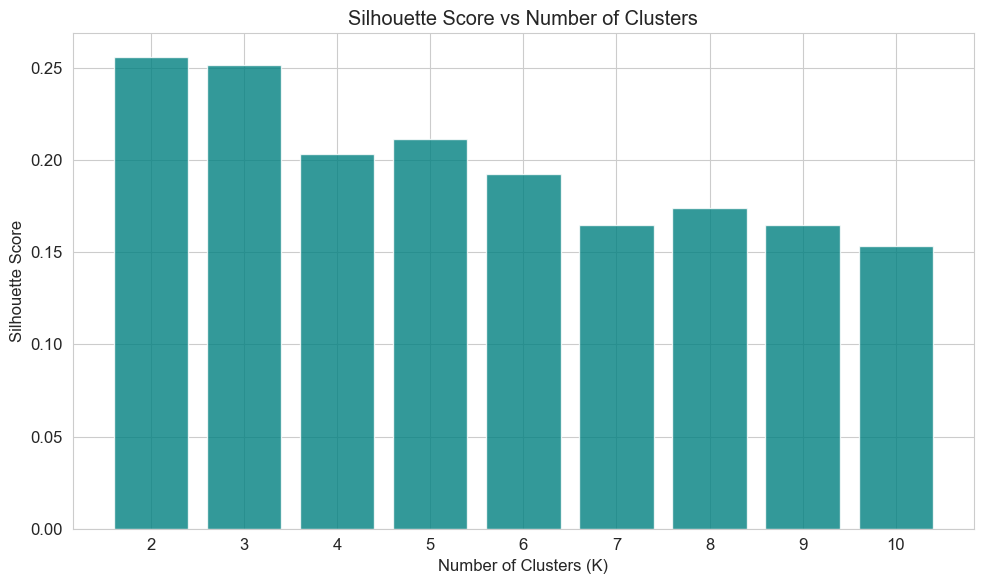


Best K from Silhouette Score: 2
Best Silhouette Score: 0.2560


In [25]:
# Silhouette Score
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    sil_scores.append(score)
    print(f"K={k}  |  Silhouette Score: {score:.4f}  |  Inertia: {km.inertia_:.2f}")

plt.figure(figsize=(10, 6))
plt.bar(K_range, sil_scores, color='teal', alpha=0.8)
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150)
plt.show()

# Select best K
best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"\nBest K from Silhouette Score: {best_k}")
print(f"Best Silhouette Score: {max(sil_scores):.4f}")


In [26]:
# Fit Final K-Means Model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())



Cluster distribution:
Cluster
0     1952
1    10378
Name: count, dtype: int64


In [28]:
# Cluster Profiling
# Mean of original features per cluster
cluster_profile = df.groupby('Cluster')[
    ['Administrative', 'Administrative_Duration',
     'Informational', 'Informational_Duration',
     'ProductRelated', 'ProductRelated_Duration',
     'BounceRates', 'ExitRates', 'PageValues',
     'SpecialDay', 'Revenue']
].mean().round(3)

print("\nCluster Profile (mean values):")
print(cluster_profile)



Cluster Profile (mean values):
         Administrative  Administrative_Duration  Informational  \
Cluster                                                           
0                 7.135                  290.309          2.247   
1                 1.409                   41.416          0.176   

         Informational_Duration  ProductRelated  ProductRelated_Duration  \
Cluster                                                                    
0                       182.693          90.392                 3545.798   
1                         6.594          20.698                  752.536   

         BounceRates  ExitRates  PageValues  SpecialDay  Revenue  
Cluster                                                           
0              0.006      0.019       9.969       0.031    0.276  
1              0.025      0.048       5.122       0.067    0.132  



Conversion Rate per Cluster (%):
Cluster
0    27.56
1    13.20
Name: Revenue, dtype: float64


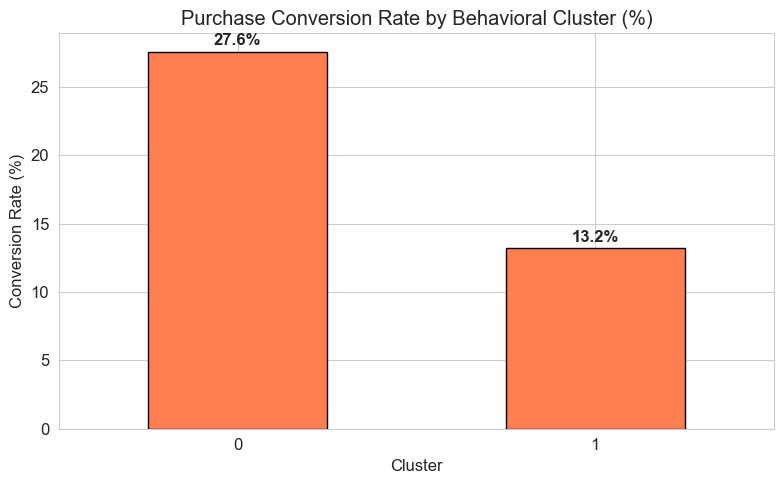

In [30]:
# Conversion Rate per Cluster
conversion_per_cluster = df.groupby('Cluster')['Revenue'].mean() * 100
print("\nConversion Rate per Cluster (%):")
print(conversion_per_cluster.round(2))

plt.figure(figsize=(8, 5))
conversion_per_cluster.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Purchase Conversion Rate by Behavioral Cluster (%)')
plt.xlabel('Cluster')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(conversion_per_cluster):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('conversion_per_cluster.png', dpi=150)
plt.show()


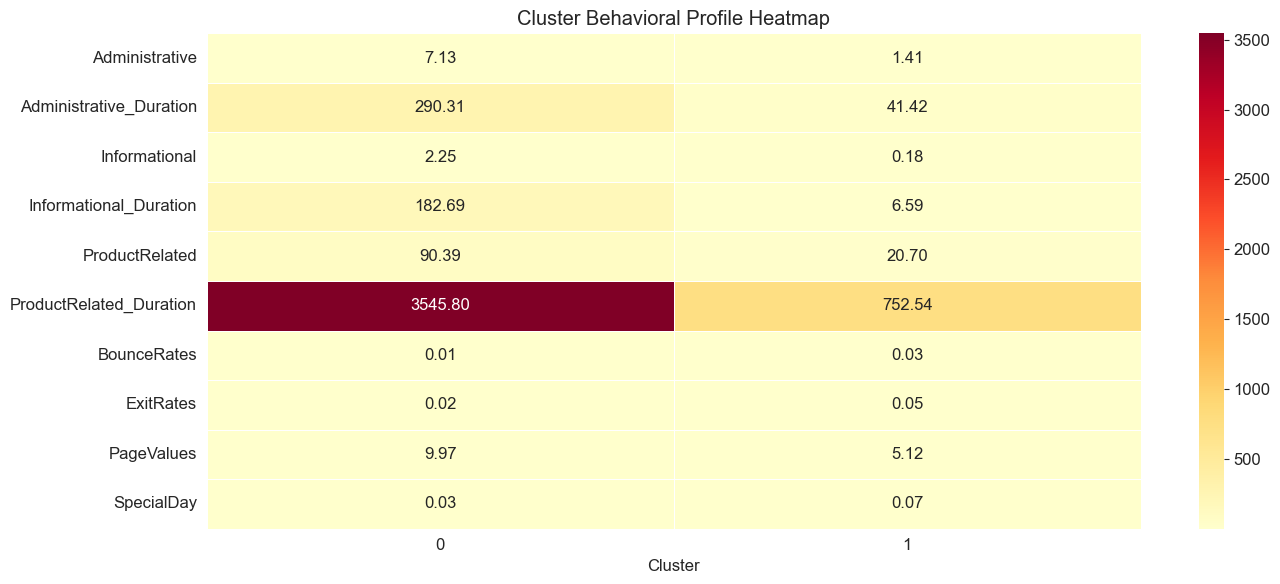

In [31]:
#  Cluster Heatmap
plt.figure(figsize=(14, 6))
profile_for_heatmap = cluster_profile.drop('Revenue', axis=1)
sns.heatmap(profile_for_heatmap.T, annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Behavioral Profile Heatmap')
plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150)
plt.show()

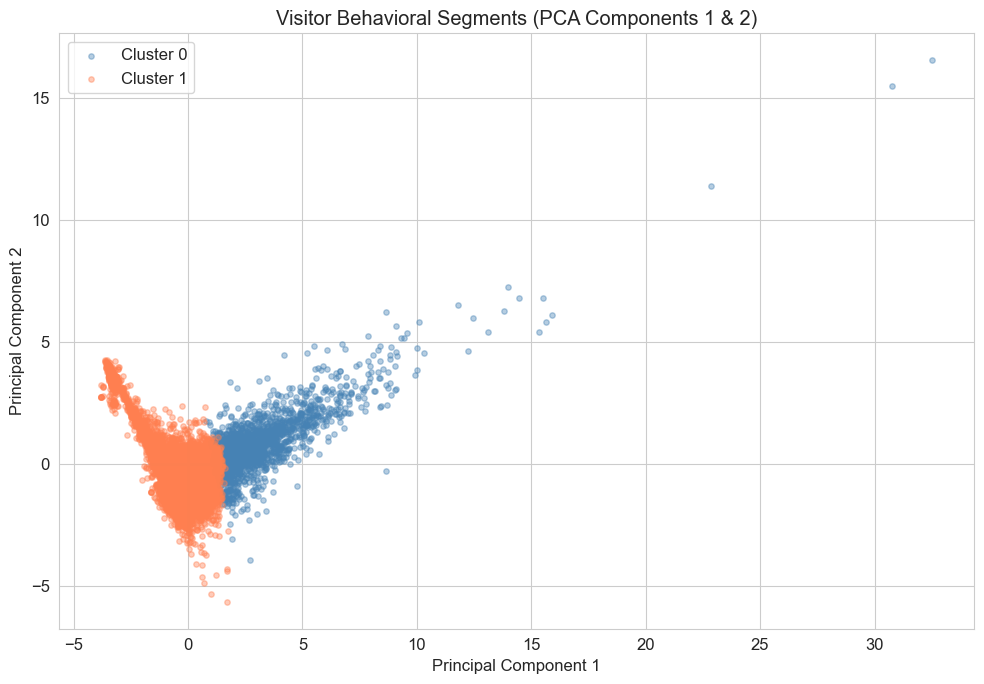

In [32]:
# PCA Scatter Plot Colored by Cluster 
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'coral', 'green', 'purple',
          'orange', 'brown', 'pink', 'gray']
for i in range(best_k):
    mask = cluster_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.4, s=15)
plt.title('Visitor Behavioral Segments (PCA Components 1 & 2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150)
plt.show()

Step 6 — Logistic Regression

In [33]:
# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves 84.5/15.5 class ratio in both sets
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set size: 9864
Test set size: 2466

Training class distribution:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64

Test class distribution:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


In [34]:
# Train Logistic Regression with class_weight='balanced'
model = LogisticRegression(
    class_weight='balanced',   # corrects for 84.5/15.5 imbalance
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
model.fit(X_train, y_train)

print("\nModel trained successfully.")
print(f"Number of iterations: {model.n_iter_}")



Model trained successfully.
Number of iterations: [13]


In [35]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of purchase

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Purchase       0.94      0.89      0.92      2084
    Purchase       0.55      0.71      0.62       382

    accuracy                           0.87      2466
   macro avg       0.75      0.80      0.77      2466
weighted avg       0.88      0.87      0.87      2466



Confusion Matrix:
[[1861  223]
 [ 109  273]]

True Negatives  (Correctly predicted No Purchase): 1861
False Positives (Incorrectly predicted Purchase):  223
False Negatives (Missed actual Purchases):         109
True Positives  (Correctly predicted Purchase):    273


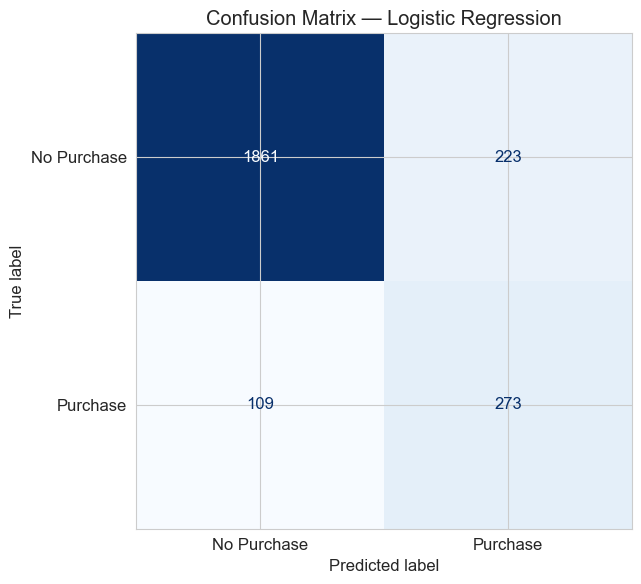

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives  (Correctly predicted No Purchase): {cm[0][0]}")
print(f"False Positives (Incorrectly predicted Purchase):  {cm[0][1]}")
print(f"False Negatives (Missed actual Purchases):         {cm[1][0]}")
print(f"True Positives  (Correctly predicted Purchase):    {cm[1][1]}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


ROC-AUC Score: 0.8739


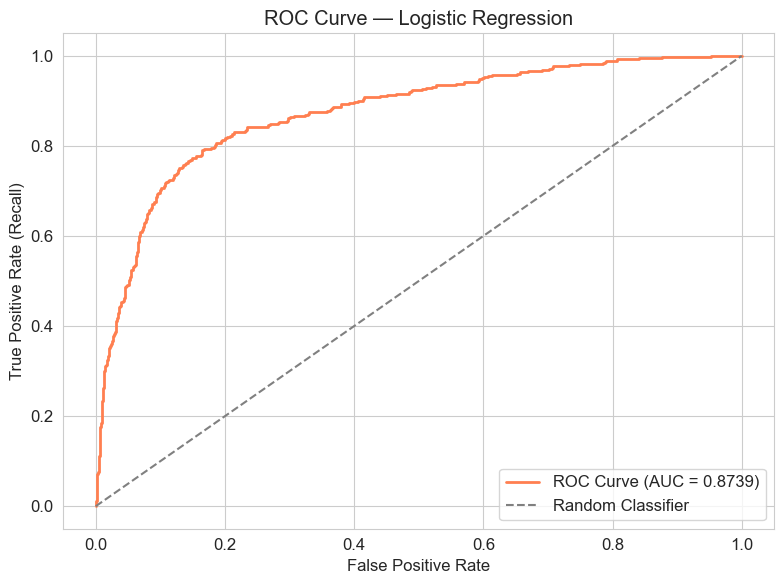

In [37]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='coral', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.title('ROC Curve — Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [38]:
# Cross-Validation (Robustness Check)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_pca, y, cv=skf, scoring='roc_auc')

print("\n" + "="*60)
print("5-FOLD STRATIFIED CROSS-VALIDATION — ROC-AUC")
print("="*60)
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\n  Mean ROC-AUC:  {cv_scores.mean():.4f}")
print(f"  Std Deviation: {cv_scores.std():.4f}")


5-FOLD STRATIFIED CROSS-VALIDATION — ROC-AUC
  Fold 1: 0.9028
  Fold 2: 0.8785
  Fold 3: 0.8790
  Fold 4: 0.9091
  Fold 5: 0.8905

  Mean ROC-AUC:  0.8920
  Std Deviation: 0.0124


Step 7 — Compare Balanced vs Unbalanced Model

UNBALANCED MODEL (no class_weight)
              precision    recall  f1-score   support

 No Purchase       0.89      0.98      0.93      2084
    Purchase       0.75      0.36      0.49       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466

BALANCED MODEL (class_weight='balanced')
              precision    recall  f1-score   support

 No Purchase       0.94      0.89      0.92      2084
    Purchase       0.55      0.71      0.62       382

    accuracy                           0.87      2466
   macro avg       0.75      0.80      0.77      2466
weighted avg       0.88      0.87      0.87      2466



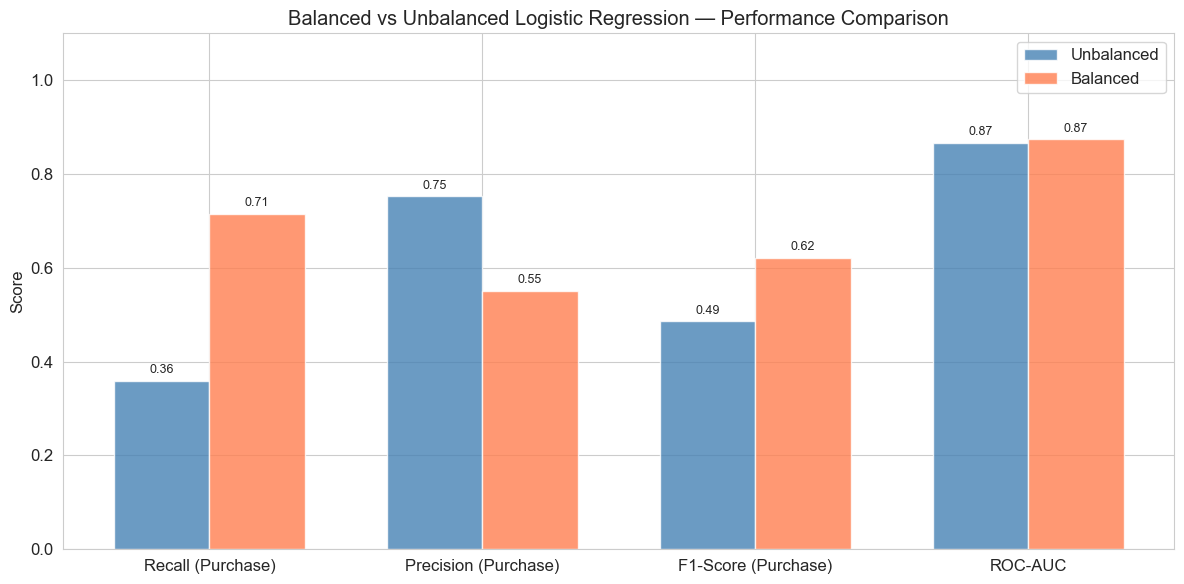

In [42]:
# This directly supports the methodology argument for class_weight='balanced'

model_unbalanced = LogisticRegression(max_iter=1000, random_state=42)
model_unbalanced.fit(X_train, y_train)
y_pred_unbal = model_unbalanced.predict(X_test)

print("="*60)
print("UNBALANCED MODEL (no class_weight)")
print("="*60)
print(classification_report(y_test, y_pred_unbal, target_names=['No Purchase', 'Purchase']))

print("="*60)
print("BALANCED MODEL (class_weight='balanced')")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

# Recall comparison bar chart
from sklearn.metrics import recall_score, precision_score, f1_score

metrics = {
    'Recall (Purchase)': [
        recall_score(y_test, y_pred_unbal),
        recall_score(y_test, y_pred)
    ],
    'Precision (Purchase)': [
        precision_score(y_test, y_pred_unbal),
        precision_score(y_test, y_pred)
    ],
    'F1-Score (Purchase)': [
        f1_score(y_test, y_pred_unbal),
        f1_score(y_test, y_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, model_unbalanced.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_prob)
    ]
}

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, [v[0] for v in metrics.values()],
               width, label='Unbalanced', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, [v[1] for v in metrics.values()],
               width, label='Balanced', color='coral', alpha=0.8)

ax.set_title('Balanced vs Unbalanced Logistic Regression — Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('balanced_vs_unbalanced.png', dpi=150)
plt.show()

Step 8 — Final Summary Output

In [43]:
print("\n" + "="*60)
print("FULL ANALYSIS SUMMARY")
print("="*60)

print(f"\n[1] DATASET")
print(f"    Total sessions:        {len(df)}")
print(f"    Purchasing sessions:   {y.sum()} ({y.mean()*100:.1f}%)")
print(f"    Non-purchasing:        {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")

print(f"\n[2] PCA")
print(f"    Original features:     {X_scaled.shape[1]}")
print(f"    Components retained:   {n_components_95}")
print(f"    Variance explained:    {sum(pca.explained_variance_ratio_)*100:.2f}%")

print(f"\n[3] K-MEANS CLUSTERING")
print(f"    Optimal K:             {best_k}")
print(f"    Best Silhouette Score: {max(sil_scores):.4f}")
print(f"\n    Cluster Sizes and Conversion Rates:")
for c in range(best_k):
    size = (df['Cluster'] == c).sum()
    conv = df[df['Cluster'] == c]['Revenue'].mean() * 100
    print(f"      Cluster {c}: {size:5d} sessions | Conversion Rate: {conv:.1f}%")

print(f"\n[4] LOGISTIC REGRESSION (Balanced)")
print(f"    ROC-AUC Score:         {roc_auc:.4f}")
print(f"    Cross-Val ROC-AUC:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"    Recall (Purchase):     {recall_score(y_test, y_pred):.4f}")
print(f"    Precision (Purchase):  {precision_score(y_test, y_pred):.4f}")
print(f"    F1-Score (Purchase):   {f1_score(y_test, y_pred):.4f}")

print("\n" + "="*60)
print("All plots saved as PNG files in current directory.")
print("="*60)


FULL ANALYSIS SUMMARY

[1] DATASET
    Total sessions:        12330
    Purchasing sessions:   1908 (15.5%)
    Non-purchasing:        10422 (84.5%)

[2] PCA
    Original features:     17
    Components retained:   14
    Variance explained:    96.76%

[3] K-MEANS CLUSTERING
    Optimal K:             2
    Best Silhouette Score: 0.2560

    Cluster Sizes and Conversion Rates:
      Cluster 0:  1952 sessions | Conversion Rate: 27.6%
      Cluster 1: 10378 sessions | Conversion Rate: 13.2%

[4] LOGISTIC REGRESSION (Balanced)
    ROC-AUC Score:         0.8739
    Cross-Val ROC-AUC:     0.8920 ± 0.0124
    Recall (Purchase):     0.7147
    Precision (Purchase):  0.5504
    F1-Score (Purchase):   0.6219

All plots saved as PNG files in current directory.
